In [10]:
import numpy as np
import pandas as pd
from matplotlib import cm
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv("chlor.csv")
df.head()

,Chl_a,Phy,NO2,NO3,NH4,PO4,Site,Bay,Depth
0,6.66,0.74,0.21830,0.522735,31.784807,15.317651,XVI,West Bay,1.097
1,6.45,0.78,0.21830,0.522735,31.784807,15.317651,XVI,West Bay,1.098
2,6.27,0.77,0.21830,0.522735,31.784807,15.317651,XVI,West Bay,1.098
3,6.13,0.58,0.21495,0.527931,30.446107,14.834307,XVI,West Bay,2.004
4,6.10,0.57,0.21495,0.527931,30.446107,14.834307,XVI,West Bay,2.004


In [4]:
print(f'No. of rows: {len(df)}')
df.dropna(inplace=True)
df.drop(['Phy'], axis=1, inplace=True)
print(f'After removing missing values: {len(df)}')

No. of rows: 255
After removing missing values: 109


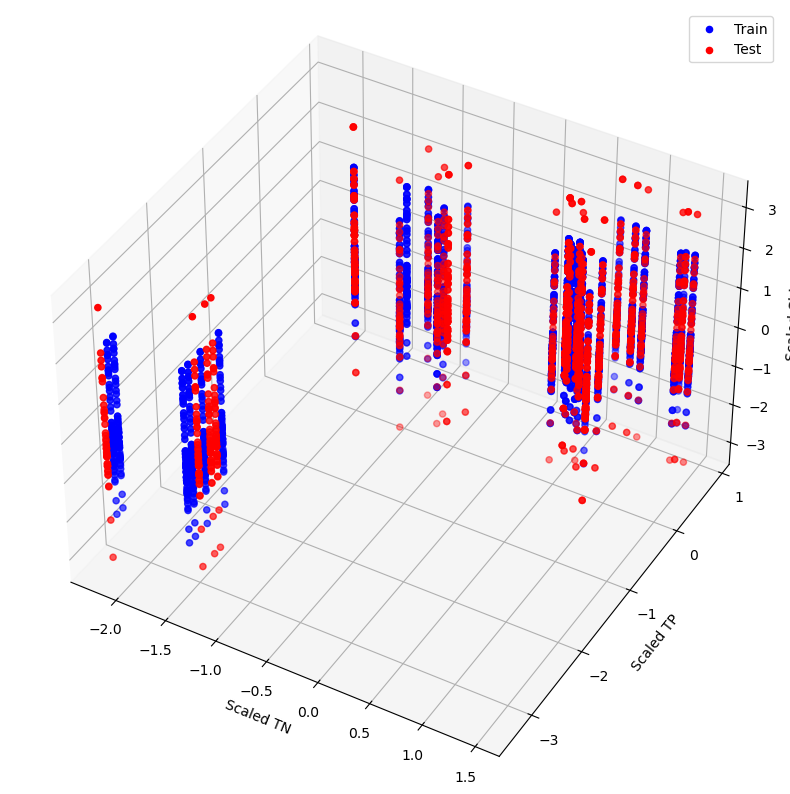

In [5]:
# Get the [NO2-], [NO3-], [NH4+], and [PO43-] as "X", then Chl-a as "y" 
X, y = df.iloc[:,1:5].to_numpy(), df['Chl_a'].to_numpy()

# Create a new X with TN (Total Nitrogen) and TP (Total Phosphorus) columns 
# TN = NO2 + NO3 + NH4; TP = PO4 
# Note: The original code provided summed the first two columns (NO2, NO3) for TN. 
# Following the original logic:
X = np.hstack((X[:,:2].sum(axis=1, keepdims=True), X[:,-1].reshape(-1,1)))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=0, stratify=df['Site'])
y_train, y_test = y_train.reshape(-1,1), y_test.reshape(-1,1)

scaler_X, scaler_y = StandardScaler(), StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train)
X_test_scaled = scaler_X.transform(X_test)
y_test_scaled = scaler_y.transform(y_test)

# Visualize 3D scatter plot
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection='3d')
ax.scatter(X_train_scaled[:,0], X_train_scaled[:,1], y_train_scaled, c='b', label='Train')
ax.scatter(X_test_scaled[:,0], X_test_scaled[:,1], y_test_scaled, c='r', label='Test')
ax.set_xlabel('Scaled TN')
ax.set_ylabel('Scaled TP')
ax.set_zlabel('Scaled Chl-a')
ax.legend()
ax.view_init(elev=40)
plt.show()

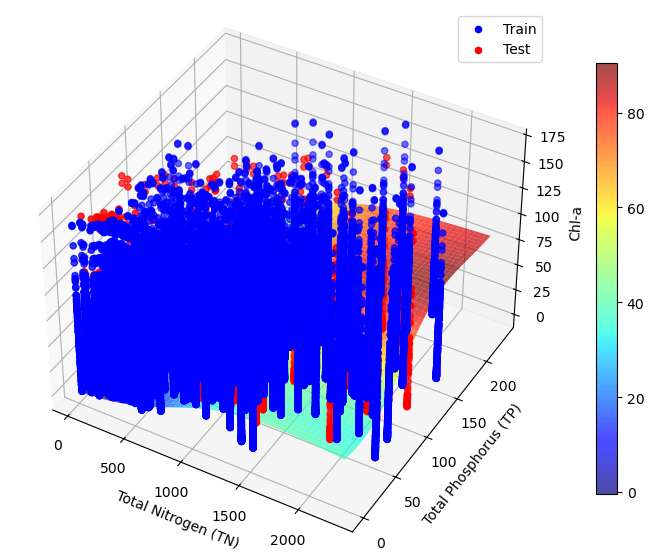

In [27]:
# Create mesh grid for TN and TP (scaled space)
vx, vy = np.meshgrid(
    np.linspace(X_train_scaled[:,0].min(), X_train_scaled[:,0].max(), 200),
    np.linspace(X_train_scaled[:,1].min(), X_train_scaled[:,1].max(), 200)
)

X_grid = np.hstack((vx.reshape(-1,1), vy.reshape(-1,1)))

# Predict Chla using ANN
vz = ANN.predict(X_grid)

# Convert back to original units
X_grid_inv = scaler_X.inverse_transform(X_grid)
Z = scaler_y.inverse_transform(vz.reshape(-1,1))

# Plot
fig = plt.figure(figsize=(12,7))
ax = fig.add_subplot(projection='3d')

# Scatter actual data
ax.scatter(X_train[:,0], X_train[:,1], y_train, c='blue', label='Train')
ax.scatter(X_test[:,0], X_test[:,1], y_test, c='red', label='Test')

# Surface prediction
surf = ax.plot_surface(
    X_grid_inv[:,0].reshape(vx.shape),
    X_grid_inv[:,1].reshape(vx.shape),
    Z.reshape(vx.shape),
    cmap=cm.jet,
    alpha=0.7,
    linewidth=0
)

ax.set_xlabel('Total Nitrogen (TN)')
ax.set_ylabel('Total Phosphorus (TP)')
ax.set_zlabel('Chl-a')

ax.view_init(elev=40)
ax.legend()

fig.colorbar(surf, shrink=0.8)

plt.show()

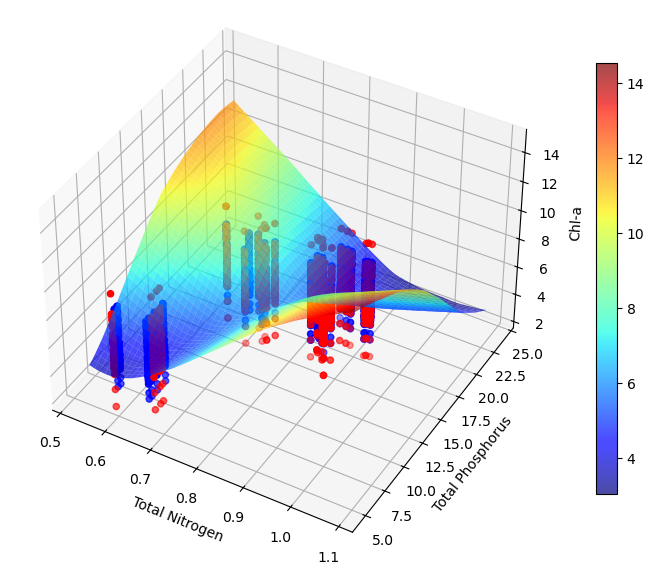

In [7]:
vx, vy = np.meshgrid(np.linspace(-3,3,200), np.linspace(-3,3,200))
X_grid = np.hstack((vx.reshape(-1,1), vy.reshape(-1,1)))
vz = ANN.predict(X_grid)

fig = plt.figure(figsize=(12,7))
ax = fig.add_subplot(projection='3d')
ax.scatter(X_train[:,0], X_train[:,1], y_train, c='b')
ax.scatter(X_test[:,0], X_test[:,1], y_test, c='r')
ax.set_xlabel('Total Nitrogen')
ax.set_ylabel('Total Phosphorus')
ax.set_zlabel('Chl-a')
ax.view_init(elev=40)

X_grid_inv = scaler_X.inverse_transform(X_grid)
Z = scaler_y.inverse_transform(vz.reshape(-1,1))

surf = ax.plot_surface(X_grid_inv[:,0].reshape(vx.shape),
                       X_grid_inv[:,1].reshape(vx.shape), 
                       Z.reshape(vx.shape),
                       linewidth=0,
                       cmap=cm.jet,
                       alpha = 0.7)
fig.colorbar(surf, shrink=0.8)
plt.show()

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# Load the global lakes dataset
df_lakes = pd.read_csv("reduced_global_lakes_data.csv")
df_lakes.head()

,Unique Lake,Latitude,Longitude,Chla,TP,TN,DO,TSS,Country,Lake Name
0,JPN11042,43.58778,144.53083,0.3,5.0,80.0,9.9,0.27,JPN,Lake Mashu - Deepest Point
1,JPN11048,36.11972,140.39028,56.0,102.0,1800.0,13.7,21.50,JPN,Kasumigaura
2,JPN11041,35.04111,135.89611,12.0,16.0,240.0,9.8,2.00,JPN,Biwa
3,JPN11048,36.04306,140.41167,58.0,117.0,793.0,11.0,21.60,JPN,Kasumigaura
4,JPN11040,35.56778,135.88167,30.0,30.0,750.0,13.0,2.00,JPN,Lake Mikata


In [20]:
# Drop rows with missing values in our target columns
df_lakes.dropna(subset=['TN', 'TP', 'Chla'], inplace=True)
print(f"Data points after cleaning: {len(df_lakes)}")

Data points after cleaning: 400


In [21]:
# Inputs: TN and TP | Output: Chla
X = df_lakes[['TN', 'TP']].to_numpy()
y = df_lakes['Chla'].to_numpy().reshape(-1, 1)

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Scaling is critical for Neural Networks
scaler_X, scaler_y = StandardScaler(), StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train).ravel()

X_test_scaled = scaler_X.transform(X_test)
y_test_scaled = scaler_y.transform(y_test).ravel()

In [22]:
# Setup search range
param_grid = {
    'hidden_layer_sizes': [(10,), (50,), (100,), (50, 50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.01], 
    'learning_rate_init': [0.001, 0.01]
}

# Perform 5-fold CV to minimize MSE
mlp = MLPRegressor(max_iter=2000, random_state=42)
grid_search = GridSearchCV(mlp, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train_scaled)

# Store the best model
ANN = grid_search.best_estimator_

# --- CRITICAL: Calculate variables for the final report ---
y_train_pred = ANN.predict(X_train_scaled)
y_test_pred = ANN.predict(X_test_scaled)

train_mse = mean_squared_error(y_train_scaled, y_train_pred)
test_mse = mean_squared_error(y_test_scaled, y_test_pred)
train_r2 = r2_score(y_train_scaled, y_train_pred)
test_r2 = r2_score(y_test_scaled, y_test_pred)

print("Tuning complete. Best architecture found.")

Tuning complete. Best architecture found.


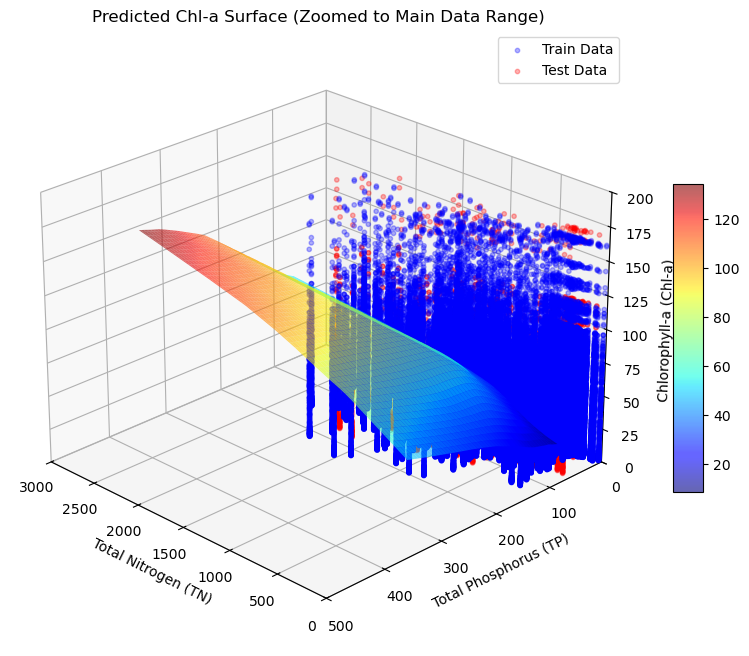

----------------------------------------
Best Architecture: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.001}
Training MSE: 0.3449
Testing MSE:  0.3919
Training R2:  0.6551
Testing R2:   0.7299


In [23]:
# 1. Create a grid of points for the prediction surface
# We use a fixed range in "scaled units" (-1 to 5) to avoid outliers stretching the plot
vx, vy = np.meshgrid(np.linspace(-1, 5, 100), 
                     np.linspace(-1, 5, 100))
X_grid_scaled = np.hstack((vx.reshape(-1, 1), vy.reshape(-1, 1)))

# 2. Predict Chl-a for the grid
vz_scaled = ANN.predict(X_grid_scaled)

# 3. Inverse transform back to original units for the plot
X_grid = scaler_X.inverse_transform(X_grid_scaled)
Z = scaler_y.inverse_transform(vz_scaled.reshape(-1, 1))

# 4. Create the 3D Plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter actual data (using small points 's=10' to see the density)
ax.scatter(X_train[:, 0], X_train[:, 1], y_train, c='blue', label='Train Data', alpha=0.3, s=10)
ax.scatter(X_test[:, 0], X_test[:, 1], y_test, c='red', label='Test Data', alpha=0.3, s=10)

# Plot the predicted surface
surf = ax.plot_surface(X_grid[:, 0].reshape(vx.shape),
                       X_grid[:, 1].reshape(vx.shape),
                       Z.reshape(vx.shape),
                       cmap=cm.jet, alpha=0.6, linewidth=0)

# --- FIXING THE PLOT VIEW ---
# We set limits to focus on where 95% of the data lives (ignoring 20,000+ TN outliers)
ax.set_xlim(0, 3000) 
ax.set_ylim(0, 500)  
ax.set_zlim(0, 200)

ax.set_xlabel('Total Nitrogen (TN)')
ax.set_ylabel('Total Phosphorus (TP)')
ax.set_zlabel('Chlorophyll-a (Chl-a)')
ax.set_title('Predicted Chl-a Surface (Zoomed to Main Data Range)')
ax.view_init(elev=25, azim=135) # Better angle to see the slope
fig.colorbar(surf, shrink=0.5, aspect=10)
plt.legend()
plt.show()

# Final Report Summary
print("-" * 40)
print(f"Best Architecture: {grid_search.best_params_}")
print(f"Training MSE: {train_mse:.4f}")
print(f"Testing MSE:  {test_mse:.4f}")
print(f"Training R2:  {train_r2:.4f}")
print(f"Testing R2:   {test_r2:.4f}")

Best Architecture Found: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (10,), 'learning_rate_init': 0.001}
Training MSE (scaled): 0.3681
Testing MSE (scaled):  0.4821
Training R2:  0.6319
Testing R2:   0.6677


C:\Users\Edmerald\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


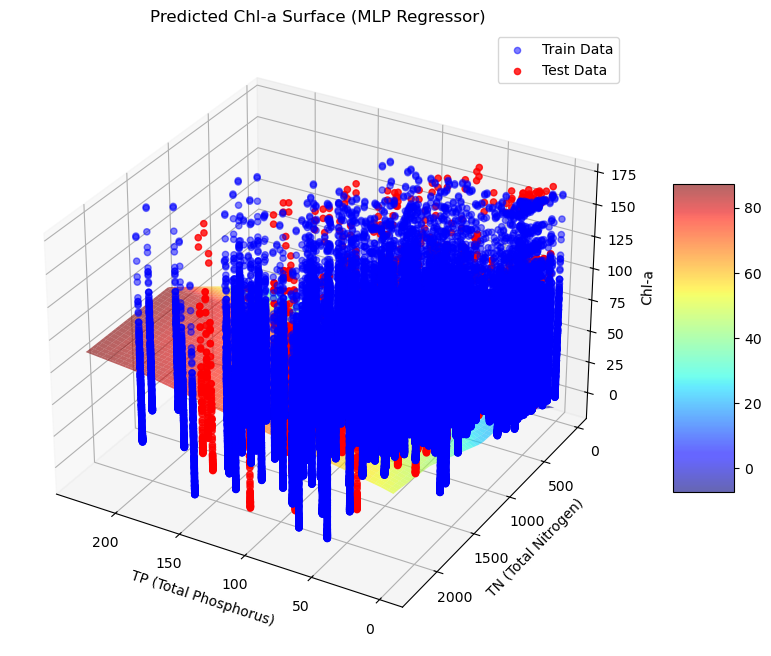

In [28]:
import numpy as np
import pandas as pd
from matplotlib import cm
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load the dataset
df = pd.read_csv("reduced_global_lakes_data.csv")

# 2. Preprocessing
# Select inputs (TP, TN) and output (Chla)
X = df[['TP', 'TN']].to_numpy()
y = df['Chla'].to_numpy().reshape(-1, 1)

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling inputs and outputs
scaler_X, scaler_y = StandardScaler(), StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train)
X_test_scaled = scaler_X.transform(X_test)
y_test_scaled = scaler_y.transform(y_test)

# 3. Hyperparameter Tuning using GridSearchCV
param_grid = {
    'hidden_layer_sizes': [(10,), (50,), (100,), (50, 50), (100, 50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.01],
    'learning_rate_init': [0.001, 0.01] 
}

mlp = MLPRegressor(max_iter=2000, random_state=42)
grid_search = GridSearchCV(mlp, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train_scaled.ravel())

# 4. Model Evaluation
ANN = grid_search.best_estimator_
y_train_pred = ANN.predict(X_train_scaled)
y_test_pred = ANN.predict(X_test_scaled)

print(f"Best Architecture Found: {grid_search.best_params_}")
print(f"Training MSE (scaled): {mean_squared_error(y_train_scaled, y_train_pred):.4f}")
print(f"Testing MSE (scaled):  {mean_squared_error(y_test_scaled, y_test_pred):.4f}")
print(f"Training R2:  {r2_score(y_train_scaled, y_train_pred):.4f}")
print(f"Testing R2:   {r2_score(y_test_scaled, y_test_pred):.4f}")

# 5. 3D Visualization of the Prediction Surface
# Create a grid for the surface plot
min_vals = X_train_scaled.min(axis=0)
max_vals = X_train_scaled.max(axis=0)
vx, vy = np.meshgrid(np.linspace(min_vals[0], max_vals[0], 100), 
                     np.linspace(min_vals[1], max_vals[1], 100))
X_grid = np.hstack((vx.reshape(-1,1), vy.reshape(-1,1)))
vz_scaled = ANN.predict(X_grid)

# Inverse transform to original units
X_grid_inv = scaler_X.inverse_transform(X_grid)
Z_inv = scaler_y.inverse_transform(vz_scaled.reshape(-1,1))

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(projection='3d')

# Plot training and testing data points
ax.scatter(X_train[:, 0], X_train[:, 1], y_train, c='blue', alpha=0.5, label='Train Data')
ax.scatter(X_test[:, 0], X_test[:, 1], y_test, c='red', alpha=0.8, label='Test Data')

# Plot the predicted surface
surf = ax.plot_surface(X_grid_inv[:, 0].reshape(vx.shape),
                       X_grid_inv[:, 1].reshape(vx.shape),
                       Z_inv.reshape(vx.shape),
                       linewidth=0, cmap=cm.jet, alpha=0.6)

ax.set_xlabel('TP (Total Phosphorus)')
ax.set_ylabel('TN (Total Nitrogen)')
ax.set_zlabel('Chl-a')
ax.set_title('Predicted Chl-a Surface (MLP Regressor)')
ax.legend()
ax.view_init(elev=30, azim=120)
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()